In [25]:
#Import Test class into this notebook (needs to be in same directory)
%run test_class.ipynb

In [36]:
# Analyze a single test 
df_1 = pd.read_csv('visit_data/TR000101_20220630_MiPACE_visit_data.csv') #replace with your own file
test_1 = Test(df_1)

In [40]:
"""
create_test_summary() method creates a dataframe containing summary statistics for the test with rows for each stage
and columns for the following metrics:
- Analysis Start Time: The start time of the analysis window.
- Analysis End Time: The end time of the analysis window.
- Velocity (km/h)
- Grade (%)
- Stage (#)
- RPE (at end of stage)
- Lactate (mmol/L): The first lactate measurement after the end of the stage or the last measurement prior if none after.
- VO2 (L/min): Average VO2 during analysis window.
- VO2 (ml/kg/min): Average VO2/weight during analysis window.
- HR (bpm): Average HR during analysis window.
- RQ: Average RQ during analysis window.
- True VO2 max: True if the average RQ during the analysis window is greater than rq_threshold.
- Steady State: True if variance (std/mean) for smoothed VO2 is less than steady_state_threshold.

Parameters (all optional):
window_size_seconds: int, default=50
    The window size in seconds calculations (final x seconds of stage).
rq_threshold: float, default=1.0
    The RQ threshold to determine if it is a true VO2 max.
smoothing_window: int, default=3
    The window size for smoothing to calculate the rolling mean and standard deviation for steady state calculations.
steady_state_threshold: float, default=0.02
    The steady state threshold for variance of VO2.
"""
#Create a summary using non-default parameters, omit any/all parameters to use defaults
summary = test_1.create_test_summary(window_size_seconds=40, rq_threshold=1.1, smoothing_window=5, steady_state_threshold=0.05)  
summary


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:697: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:08:53' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis Start Time'] = str(start_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:698: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:09:33' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis End Time'] = str(end_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:723: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version 

,Analysis Start Time,Analysis End Time,Velocity (km/h),Grade (%),Stage (#),RPE (#),Lactate (mmol/L),VO2 (mL/min),VO2 (mL/min/kg),HR (bpm),RQ,True VO2max? T/F,Reach Steady State? T/F
1.0,0 days 00:08:53,0 days 00:09:33,5.2,0.0,1.0,NaN,NaN,1793.612619,31.802000,119.280000,0.824400,False,False
2.0,0 days 00:11:52,0 days 00:12:32,5.8,0.0,2.0,10.0,2.1,1956.965214,34.698214,129.142857,0.860714,False,False
3.0,0 days 00:14:53,0 days 00:15:33,6.5,0.0,3.0,12.0,2.4,2152.836386,38.170323,136.161290,0.877419,False,False
4.0,0 days 00:17:53,0 days 00:18:33,7.1,0.0,4.0,12.0,2.3,2255.253929,39.986364,140.424242,0.900606,False,True
5.0,0 days 00:20:53,0 days 00:21:33,7.7,0.0,5.0,13.0,3.9,2385.458036,42.295588,145.882353,0.948235,False,True
6.0,0 days 00:22:54,0 days 00:23:34,8.3,0.0,6.0,15.0,5.3,2525.749773,44.782703,150.324324,1.003243,False,True


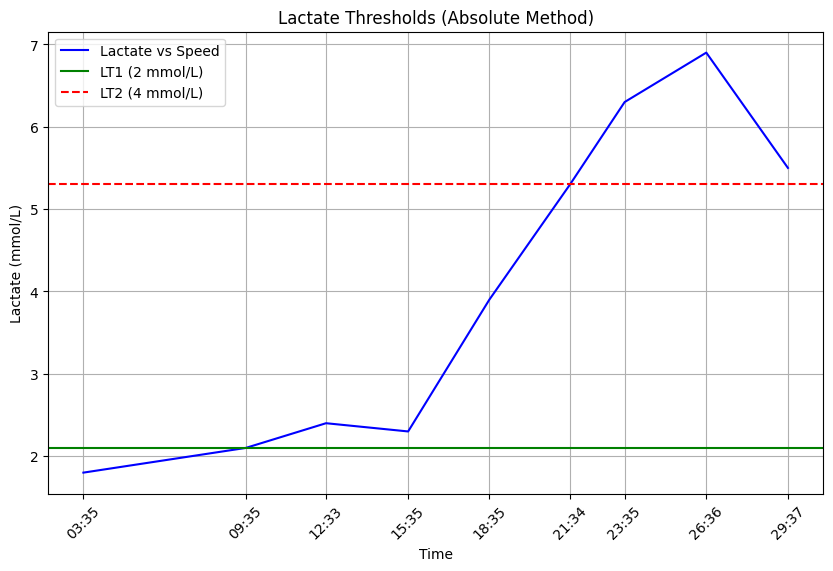

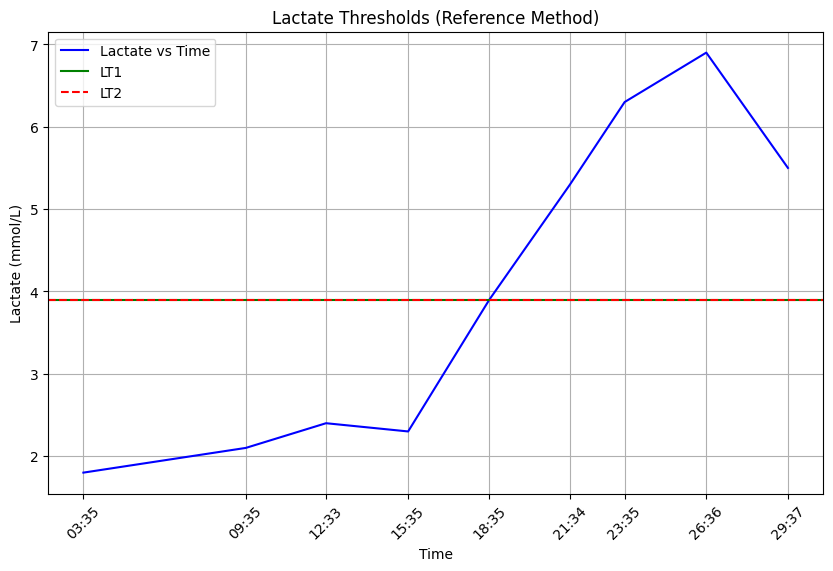

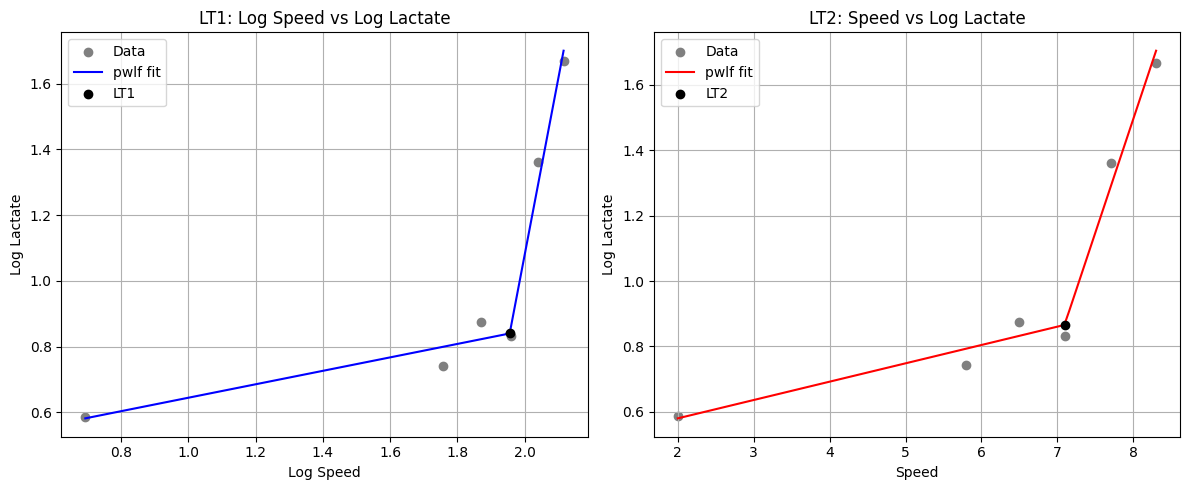

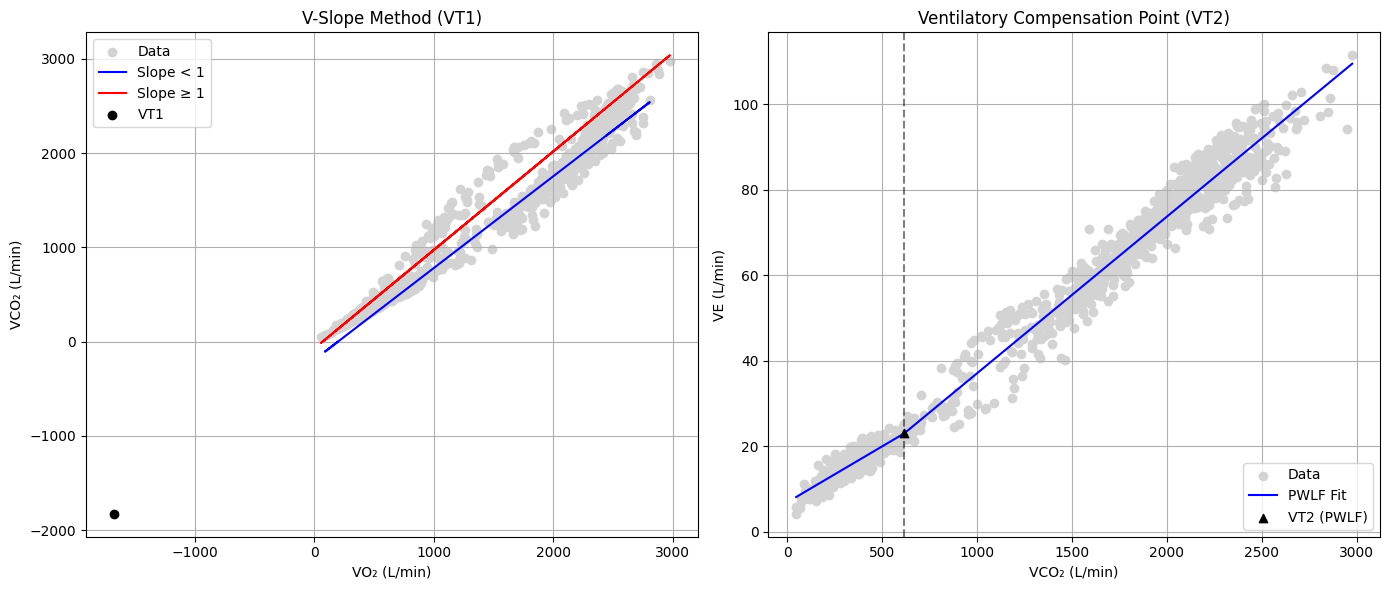

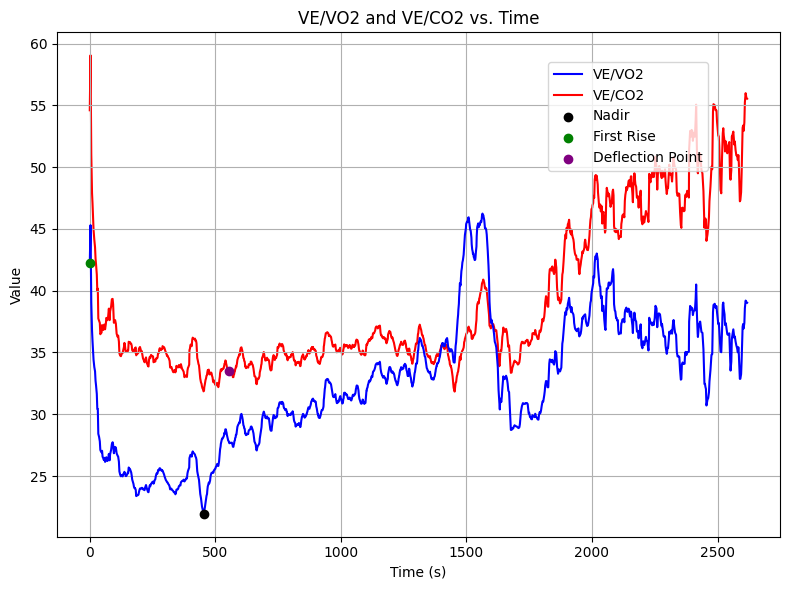

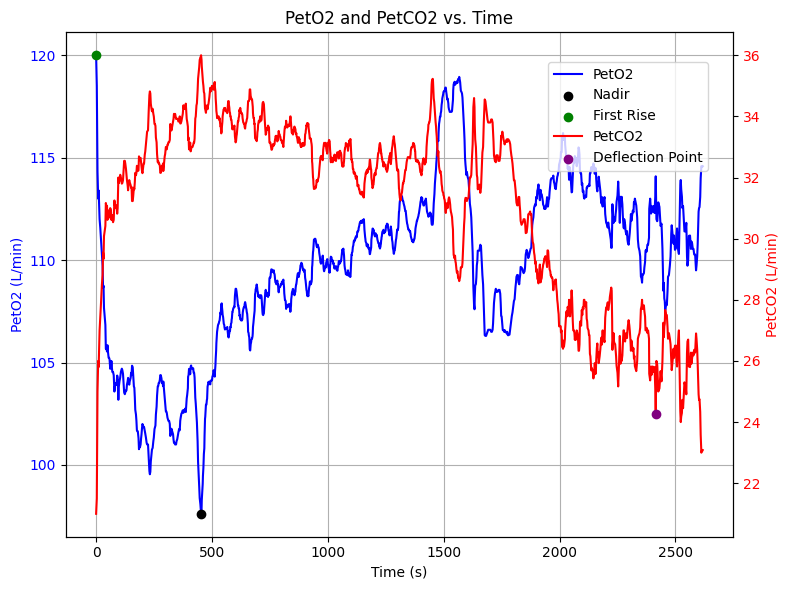

{'VO2_peak': 2536.2848298190474,
 'VO2_peak_start_time': Timedelta('0 days 00:22:50'),
 'VO2_peak_end_time': Timedelta('0 days 00:23:20'),
 'GradePeak': 0.0,
 'SpeedPeak': 8.3,
 'MarkerPeak': 6.0,
 'RQPeak': 0.9951851851851852,
 'HRPeak': 150.07407407407408,
 'EEMPeak': 12.829629629629629,
 'Fat%Peak': 531.925925925926,
 'CHO%Peak': 17941.51851851852,
 'VO2/kgPeak': 45.54296296296297,
 'Lactate-VO2Peak': 6.3,
 'RPE-VO2peak': 15,
 'True_VO2max': False,
 'LT1_abs': 2.1,
 'LT2_abs': 5.3,
 'LT1_abs_speed': 5.8,
 'LT2_abs_speed': 8.3,
 'LT1_abs_grade': 0.0,
 'LT2_abs_grade': 0.0,
 'LT1_ref': 3.9,
 'LT2_ref': 3.9,
 'LT1_ref_speed': 7.7,
 'LT2_ref_speed': 7.7,
 'LT1_ref_grade': 0.0,
 'LT2_ref_grade': 0.0,
 'LT1_log': 2.317133637468716,
 'LT1_log_speed': 7.06987210331867,
 'LT1_log_r2': 0.9859006237004515,
 'LT2_semilog': 7.094076490640033,
 'LT2_semilog_speed': 2.3765778726940128,
 'LT2_semi_log_r2': 0.9851496913514596,
 'VT1_vo2_level_v-slope': -1677.1044419356585,
 'VT1_vco2_level_v-slope':

In [41]:
"""
get_all_metrics() method returns a dictionary containing VO2 max, VT1/VT2, and LT1/LT2 metrics for the test. 
Error related entries are included if a specific metric could not be calculated.

Parameters (all optional):
vo2_window_size_seconds: int, default=50
    The window size in seconds to calculate VO2 max.
vt_window_size_seconds: int, default=30
    The window size in seconds to calculate VT1/VT2.
rq_threshold: float, default=1.0
    The RQ threshold to determine if it is a true VO2 max.
plot: bool, default=False
    If True, plots corresponding figures for the metric calculation.
    **Note that this will create figures for all LT1/LT2 and VT1/VT2 methods, to plot individual graphs, functions must run seperately**
    Only use for limited numbers of tests, as it will create a lot of figures.
"""
#get all metrics shown with default parameters, but plotting is turned on
test_1.get_all_metrics(plot=True)

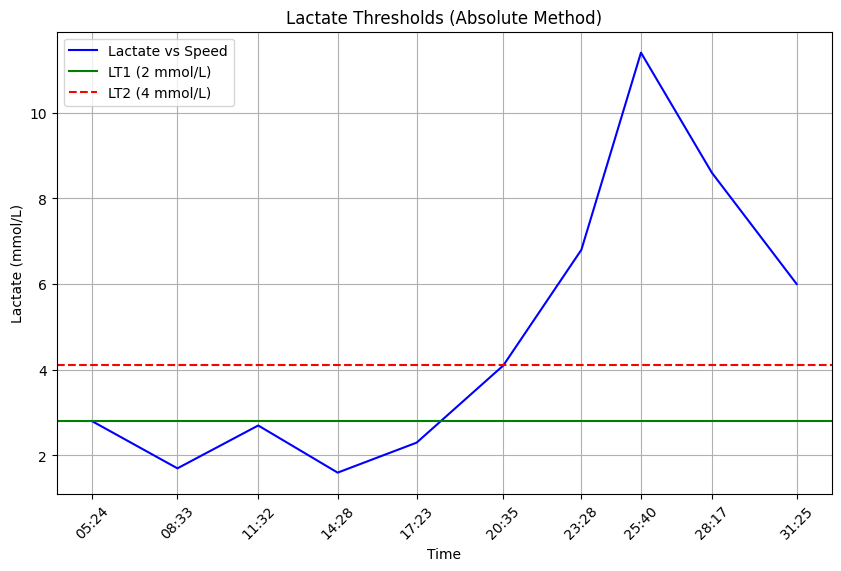

{'LT1_abs': 2.8,
 'LT2_abs': 4.1,
 'LT1_abs_speed': 6.7,
 'LT2_abs_speed': 9.8,
 'LT1_abs_grade': 0,
 'LT2_abs_grade': 0}

In [18]:
#Isolating individual functions
test_1.lt_abs_vals(plot=True) # LT reference values

In [42]:
#Analyzing a folder of data
path = r'visit_data' # name of folder containing test data files
filenames = glob.glob(os.path.join(path, "*.csv"))
test_list = []
for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_list.append(test)

In [44]:
summary_folder = 'stage_summaries_csv' # name of folder to save summary files
rows = []
for test in test_list:
    result = test.get_all_metrics() 
    result['name'] = test.name
    rows.append(result)
    summary = test.create_test_summary()
    #summary.to_parquet(f"{summary_folder}/{test.name}_summary.parquet", index=False)
    summary.to_csv(f"{summary_folder}/{test.name}_summary.csv", index=False)

df = pd.DataFrame(rows).set_index('name')
#df.to_parquet(f"combined_summaries.parquet") #name of combined summary file
df.to_csv(f"combined_summaries.csv")


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:697: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:08:23' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis Start Time'] = str(start_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:698: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:09:13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis End Time'] = str(end_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_77612/154011014.py:723: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version 

In [21]:
#View first 5 rows of the resulting dataframe
df.head()

,VO2_peak,VO2_peak_start_time,VO2_peak_end_time,GradePeak,SpeedPeak,MarkerPeak,RQPeak,HRPeak,EEMPeak,Fat%Peak,...,VT2_time_pet,VT2_speed_pet,VT2_grade_pet,lt_abs_vals_error,lt_ref_vals_error,lt_log_semilog_error,vt1_vt2_VE_error,get_VO2_peak_time_metrics_error,vt1_vt2_vo2_vco2_error,vt1_vt2_pet_error
name,,,,,,,,,,,,,,,,,,,,,
TR000207_20221201,3090.837810,0 days 00:28:01,0 days 00:28:31,0.0,2.0,0.0,1.006296,195.407407,15.164074,867.185185,...,0 days 00:34:53,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TR000199_20220503,4929.936884,0 days 00:21:01,0 days 00:21:31,0.0,9.9,5.0,0.940000,186.857143,24.322143,7429.107143,...,0 days 00:22:43,10.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TR000143_20220804,3608.790737,0 days 00:28:16,0 days 00:28:46,4.0,8.8,8.0,1.030435,189.217391,18.103913,0.000000,...,0 days 00:29:42,8.8,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TR000137_20220527,4378.285853,0 days 00:26:15,0 days 00:26:45,0.0,2.0,0.0,1.000909,173.818182,21.685909,598.909091,...,0 days 00:35:34,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TR000194_20220316,4657.398123,0 days 00:28:49,0 days 00:29:19,0.0,11.6,8.0,0.841923,172.461538,21.937692,17370.807692,...,0 days 00:28:47,11.6,0.0,cannot unpack non-iterable NoneType object,cannot unpack non-iterable NoneType object,zero-size array to reduction operation minimum...,NaN,NaN,NaN,NaN


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, TR000207_20221201 to TR000138_20220414
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   VO2_peak                         605 non-null    float64        
 1   VO2_peak_start_time              605 non-null    timedelta64[ns]
 2   VO2_peak_end_time                605 non-null    timedelta64[ns]
 3   GradePeak                        605 non-null    float64        
 4   SpeedPeak                        605 non-null    float64        
 5   MarkerPeak                       605 non-null    float64        
 6   RQPeak                           605 non-null    float64        
 7   HRPeak                           605 non-null    float64        
 8   EEMPeak                          605 non-null    float64        
 9   Fat%Peak                         605 non-null    float64        
 10  CHO%Peak                 

In [23]:
#Show the tests where a specific metric could not be calculated
print(df[pd.notnull(df['vt1_vt2_pet_error'])].index) #replace lt_abs_vals_error with the name of the function you want to check
                                                     #format remains constant: <function_name>_error

Index(['TR000263_20220608', 'TR000198_20221207', 'TR000171_20220906'], dtype='object', name='name')
